## 1) Import và setup

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

# --- Theme tương tự file visualize_hcm_pretty.py ---


def set_theme(dark=False):
    if dark:  # giao diện tối
        sns.set_theme(context="notebook", style="darkgrid", palette="tab10", font_scale=1.12)
        plt.rcParams.update({
            "figure.figsize": (9.8, 5.8),
            "figure.dpi": 130,
            "axes.edgecolor": "#444",
            "axes.facecolor": "#1E1E1E",
            "figure.facecolor": "#1E1E1E",
            "axes.labelcolor": "#E6E6E6",
            "text.color": "#E6E6E6",
            "xtick.color": "#CCCCCC",
            "ytick.color": "#CCCCCC",
            "axes.titlesize": 13,
            "axes.titleweight": "bold",
            "axes.labelsize": 12,
            "savefig.bbox": "tight",
            "grid.color": "#444444",
            "grid.alpha": 0.5,
        })
    else:     # giao diện sáng (nền trắng)
        sns.set_theme(context="notebook", style="whitegrid", palette="tab10", font_scale=1.12)
        plt.rcParams.update({
            "figure.figsize": (9.8, 5.8),
            "figure.dpi": 130,
            "axes.edgecolor": "#222",
            "axes.facecolor": "white",
            "figure.facecolor": "white",
            "axes.labelcolor": "black",
            "text.color": "black",
            "xtick.color": "black",
            "ytick.color": "black",
            "axes.titlesize": 13,
            "axes.titleweight": "bold",
            "axes.labelsize": 12,
            "savefig.bbox": "tight",
        })

# Dùng nền trắng:
set_theme(dark=False)

# Khi lưu ảnh muốn nền trắng chắc chắn:
# fig.savefig("plot.png", dpi=200, facecolor="white")


# Màu chính
PALETTE = sns.color_palette("tab10")

fmt_int  = FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", "."))
fmt_bill = FuncFormatter(lambda x, p: f"{x:,.2f}".replace(",", "_").replace(".", ",").replace("_", "."))

def safe_num(df, col):
    return pd.to_numeric(df.get(col, pd.Series(dtype=float)), errors="coerce")

print("✅ Giao diện tối (dark theme) đã bật — hiển thị dịu hơn, dễ đọc hơn.")


✅ Giao diện tối (dark theme) đã bật — hiển thị dịu hơn, dễ đọc hơn.


## 2) Đọc dữ liệu

In [12]:
# Đọc file CSV
input_csv = "moso_clean.csv"   # chỉnh đường dẫn nếu cần
df = pd.read_csv(input_csv)

# Tạo thư mục xuất
outdir = Path("viz_pretty"); outdir.mkdir(exist_ok=True)

# Các cột chuẩn
price_vnd = safe_num(df, "Giá (VND)")
price_bil = price_vnd / 1e9
area_use  = safe_num(df, "Diện tích sử dụng")
area_land = safe_num(df, "Diện tích đất")
age_days  = safe_num(df, "Số ngày từ đăng")
usage_ratio = (area_use / area_land).replace([np.inf, -np.inf], np.nan)
district = df.get("Quận/Huyện/TP", pd.Series(dtype=object)).astype("string")

print("✅ Đã đọc dữ liệu:", len(df), "bản ghi")


✅ Đã đọc dữ liệu: 2230 bản ghi


## 3) Biểu đồ 1: Phân bố giá (Hist + KDE)

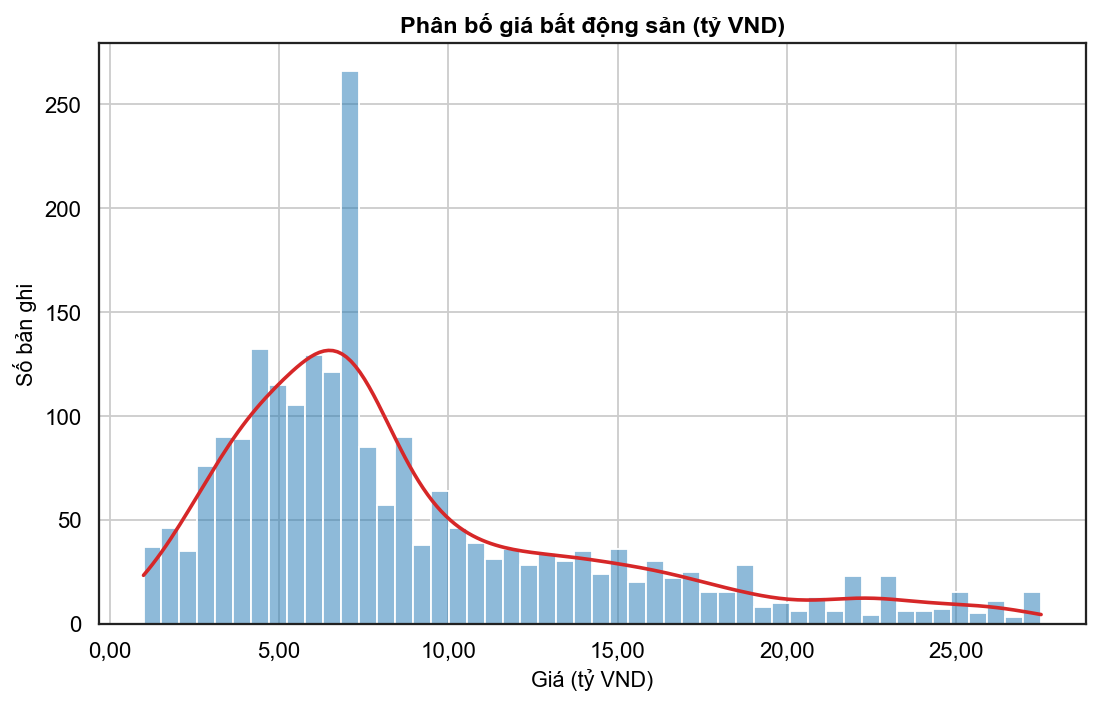

In [21]:
fig, ax = plt.subplots()
sns.histplot(price_bil.dropna(), bins=50, kde=True, ax=ax, color=PALETTE[0])
for line in ax.lines:
    line.set_linewidth(2)
    line.set_color(PALETTE[3])
ax.set_title("Phân bố giá bất động sản (tỷ VND)", weight="bold")
ax.set_xlabel("Giá (tỷ VND)")
ax.set_ylabel("Số bản ghi")
ax.xaxis.set_major_formatter(fmt_bill)
plt.show()
fig.savefig(outdir / "01_price_hist_kde.png", dpi=200)


## 4) Biểu đồ 2: Scatter Giá ↔ Diện tích

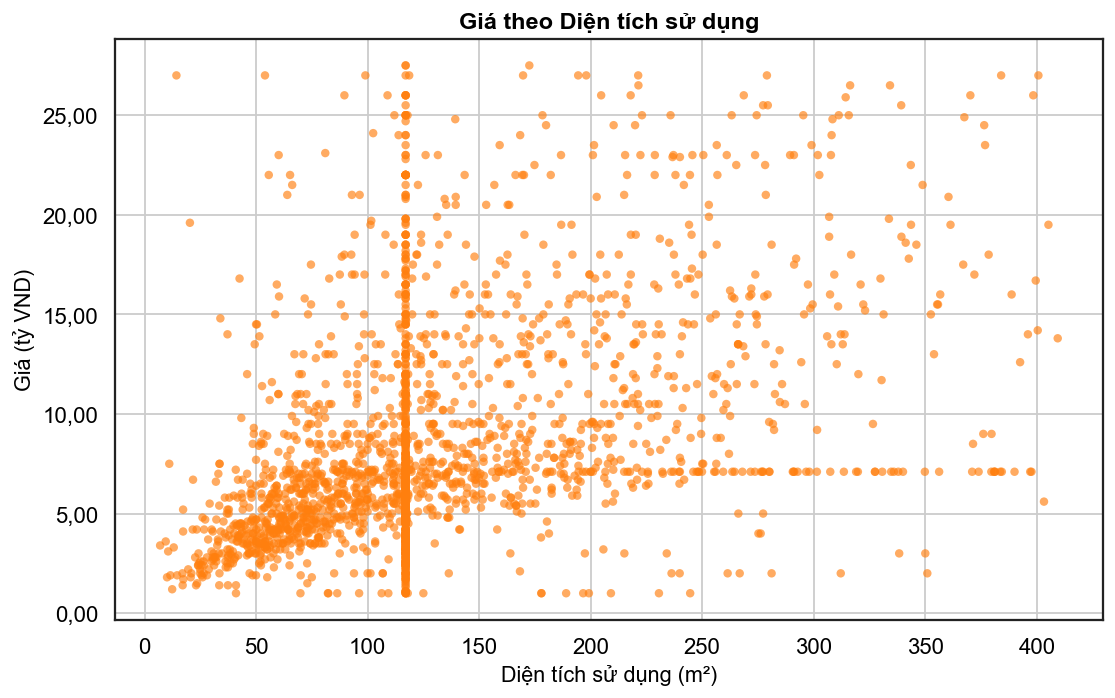

In [14]:
fig, ax = plt.subplots()
sns.scatterplot(x=area_use, y=price_bil, s=22, alpha=0.65, edgecolor="none", color=PALETTE[1])
ax.set_title("Giá theo Diện tích sử dụng", weight="bold")
ax.set_xlabel("Diện tích sử dụng (m²)")
ax.set_ylabel("Giá (tỷ VND)")
ax.yaxis.set_major_formatter(fmt_bill)
plt.show()
fig.savefig(outdir / "02_scatter_area_price.png", dpi=200)


## 5) Biểu đồ 3: Top quận theo số lượng tin

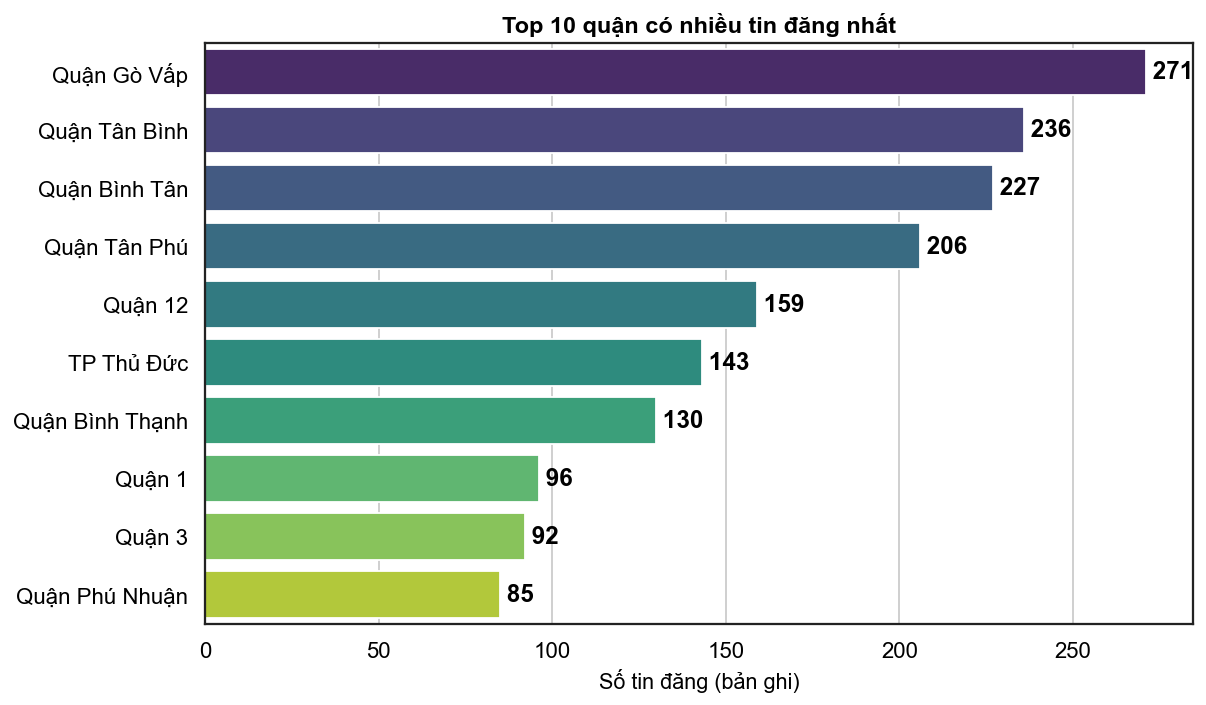

In [15]:
vc = district.dropna().value_counts().head(10)
vc_df = vc.rename("count").reset_index()
vc_df.columns = ["district", "count"]

fig, ax = plt.subplots()
sns.barplot(data=vc_df, x="count", y="district", hue="district", palette="viridis", legend=False, ax=ax)
ax.set_title("Top 10 quận có nhiều tin đăng nhất", weight="bold")
ax.set_xlabel("Số tin đăng (bản ghi)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(fmt_int)
for i, v in enumerate(vc_df["count"].values):
    ax.text(v, i, f" {int(v):,}".replace(",", "."), va="center", weight="semibold")
plt.show()
fig.savefig(outdir / "03_top_district_count.png", dpi=200)


## 6) Biểu đồ 4: Giá trung bình theo quận

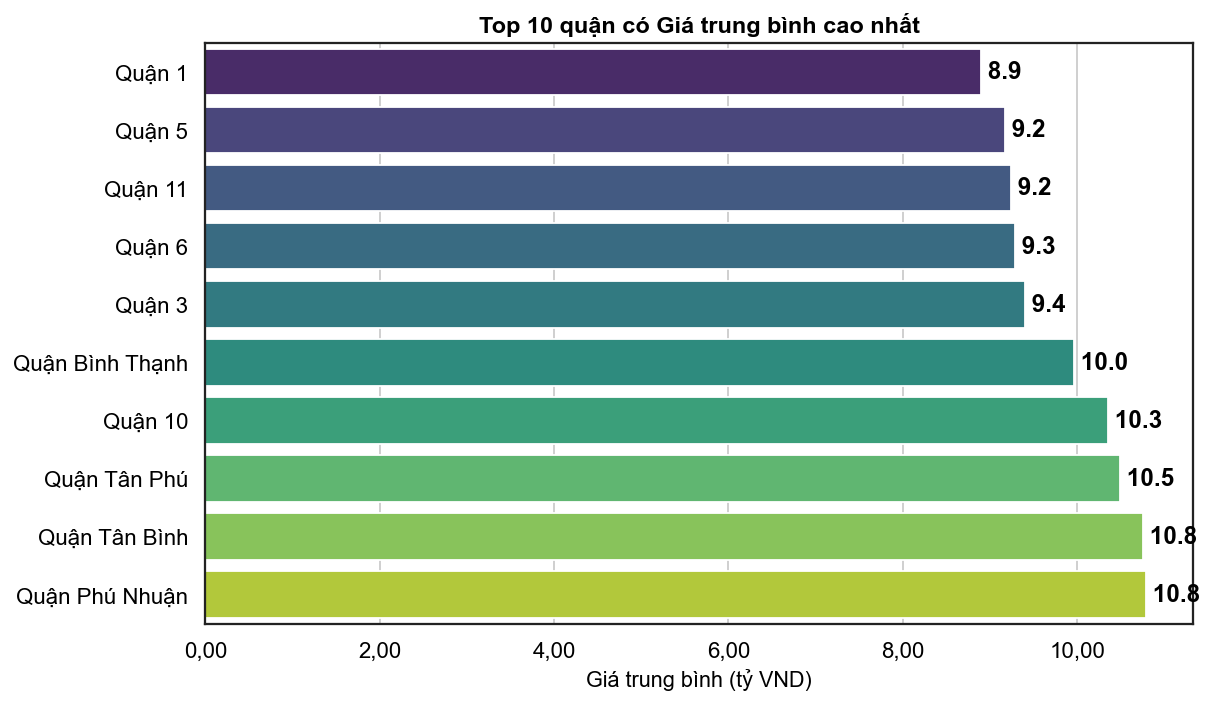

In [16]:
mean_price = (df.groupby("Quận/Huyện/TP", dropna=True)["Giá (VND)"]
              .mean().sort_values(ascending=False) / 1e9)
s_df = mean_price.head(10).sort_values().rename("price").reset_index()
s_df.columns = ["district", "price"]

fig, ax = plt.subplots()
sns.barplot(data=s_df, x="price", y="district", hue="district", palette="viridis", legend=False, ax=ax)
ax.set_title("Top 10 quận có Giá trung bình cao nhất", weight="bold")
ax.set_xlabel("Giá trung bình (tỷ VND)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(fmt_bill)
for i, v in enumerate(s_df["price"].values):
    ax.text(v, i, f" {v:.1f}", va="center", weight="semibold")
plt.show()
fig.savefig(outdir / "04_top_district_mean_price.png", dpi=200)


## 7) Biểu đồ 5: Scatter Giá ↔ Số ngày

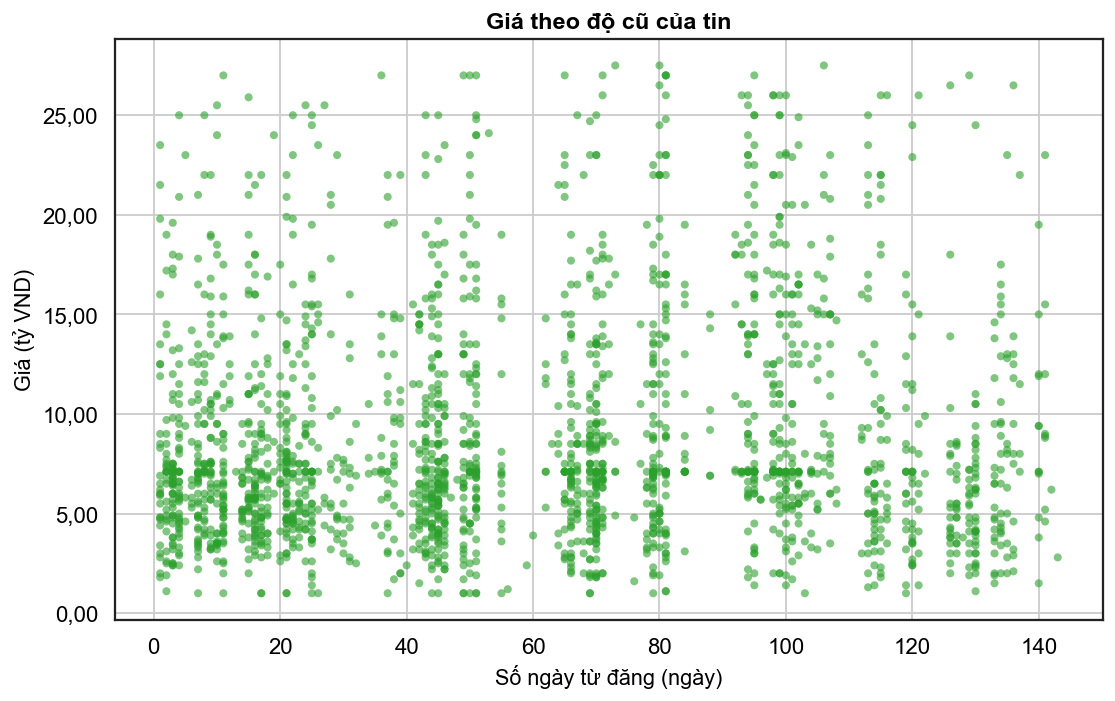

In [17]:
fig, ax = plt.subplots()
sns.scatterplot(x=age_days, y=price_bil, s=20, alpha=0.6, edgecolor="none", color=PALETTE[2])
ax.set_title("Giá theo độ cũ của tin", weight="bold")
ax.set_xlabel("Số ngày từ đăng (ngày)")
ax.set_ylabel("Giá (tỷ VND)")
ax.xaxis.set_major_formatter(fmt_int)
ax.yaxis.set_major_formatter(fmt_bill)
plt.show()
fig.savefig(outdir / "05_scatter_age_price.png", dpi=200)


## 8) Biểu đồ 6: Hist Tỷ lệ sử dụng/đất

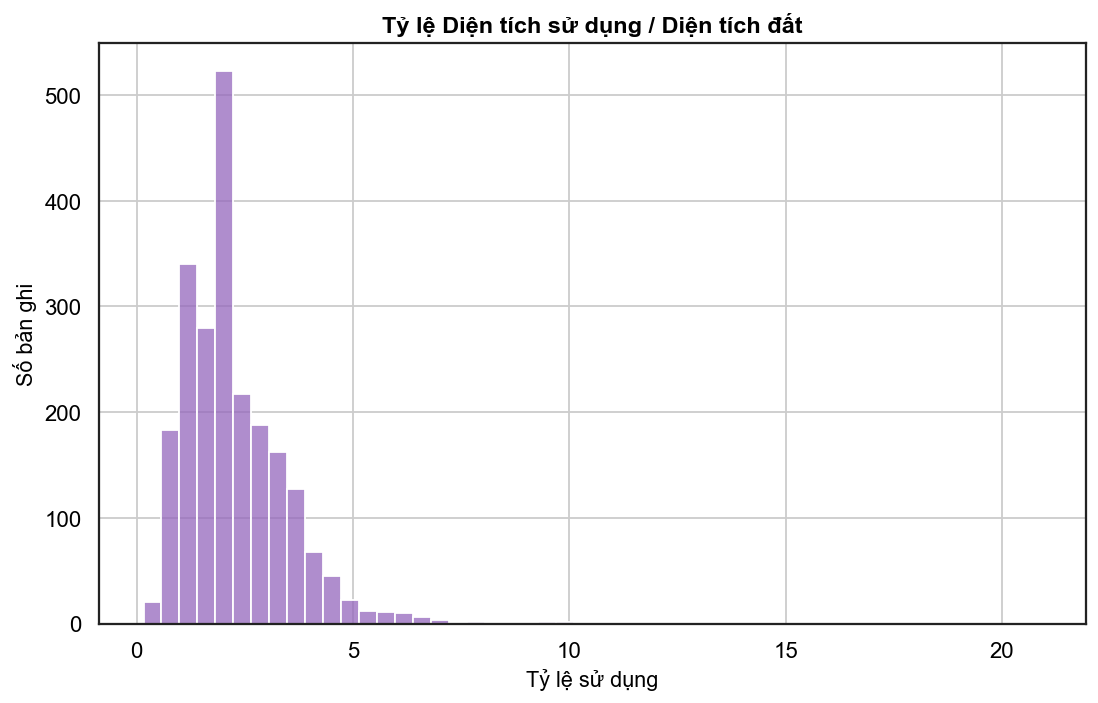

In [18]:
fig, ax = plt.subplots()
sns.histplot(usage_ratio.dropna(), bins=50, ax=ax, color=PALETTE[4])
ax.set_title("Tỷ lệ Diện tích sử dụng / Diện tích đất", weight="bold")
ax.set_xlabel("Tỷ lệ sử dụng")
ax.set_ylabel("Số bản ghi")
plt.show()
fig.savefig(outdir / "06_hist_usage_ratio.png", dpi=200)


## 9) Biểu đồ 7: Heatmap Giá ↔ Số ngày

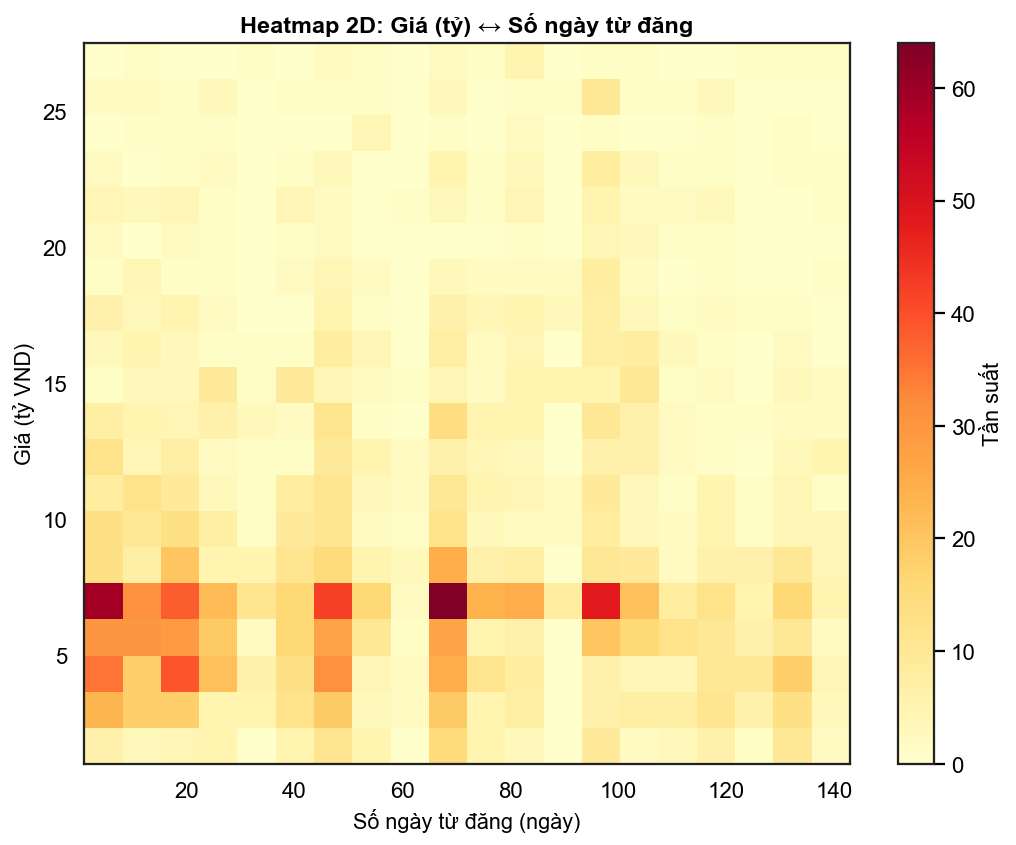

In [19]:
def plot_heatmap_2d(x, y, bins, title, xlabel, ylabel, out_png, cmap="YlOrRd"):
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    H, xe, ye = np.histogram2d(x, y, bins=bins)
    fig, ax = plt.subplots(figsize=(9.5, 7.2))
    mesh = ax.pcolormesh(xe, ye, H.T, cmap=cmap)
    plt.colorbar(mesh, ax=ax, label="Tần suất")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.set_title(title, weight="bold")
    plt.show()
    fig.savefig(out_png, dpi=200)

plot_heatmap_2d(
    x=age_days, y=price_bil, bins=20,
    title="Heatmap 2D: Giá (tỷ) ↔ Số ngày từ đăng",
    xlabel="Số ngày từ đăng (ngày)",
    ylabel="Giá (tỷ VND)",
    out_png=outdir / "07_heatmap_age_price.png"
)


## 10) Biểu đồ 8: Heatmap Giá ↔ Diện tích

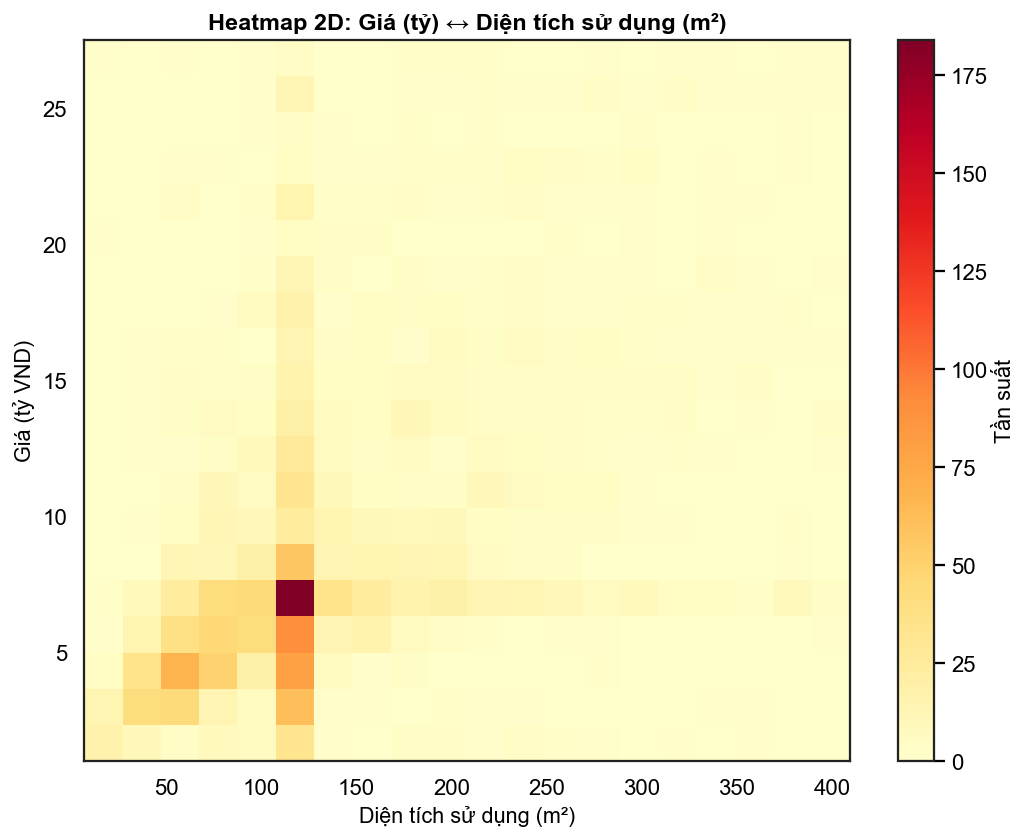

In [20]:
plot_heatmap_2d(
    x=area_use, y=price_bil, bins=20,
    title="Heatmap 2D: Giá (tỷ) ↔ Diện tích sử dụng (m²)",
    xlabel="Diện tích sử dụng (m²)",
    ylabel="Giá (tỷ VND)",
    out_png=outdir / "08_heatmap_area_price.png"
)
